# Import all required libraries

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
import matplotlib.pyplot as plt
import os
import nltk

# Importing Datasets
The datasets used in this file were downloaded from kaggle
> Link: https://www.kaggle.com/datasets/arashnic/book-recommendation-dataset

In [2]:
books = pd.read_csv('datasets/books.csv')
ratings = pd.read_csv('datasets/ratings.csv')
users = pd.read_csv('datasets/users.csv')
display("Books", books.head(), books.shape)
display("Ratings", ratings.head(), ratings.shape)
display("Users", users.head(), users.shape)

/tmp/ipykernel_119793/518856383.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('datasets/books.csv')


'Books'

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


(271360, 8)

'Ratings'

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


(1149780, 3)

'Users'

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


(278858, 3)

##### Check if Any Record has no value

In [3]:
books.isna().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

There are 2 books which has no author data in the dataset
- Let's surf through the internet and look for the missing author name
- And add it to our dataset

In [4]:
books[books['Book-Author'].isna()]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
118033,0751352497,A+ Quiz Masters:01 Earth,NaN,1999,Dorling Kindersley,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...,http://images.amazon.com/images/P/0751352497.0...
187689,9627982032,The Credit Suisse Guide to Managing Your Perso...,NaN,1995,Edinburgh Financial Publishing,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...,http://images.amazon.com/images/P/9627982032.0...


In [5]:
display(books.iloc[118033]['Book-Title'])
books.loc[118033, 'Book-Author'] = 'Dorling Kindersley'

'A+ Quiz Masters:01 Earth'

In [6]:
display(books.iloc[187689]['Book-Title'])
books.loc[187689, 'Book-Author'] = 'David Tait'

'The Credit Suisse Guide to Managing Your Personal Wealth'

Now let's check all the missing values

In [7]:
books.isna().sum()

ISBN                   0
Book-Title             0
Book-Author            0
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [8]:
users.isna().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

As we can see there are alot of missing value in age column, and let's drop age column to avoid biased recommendations

In [9]:
users.drop(columns=['Age'], inplace=True)
users.isna().sum()

User-ID     0
Location    0
dtype: int64

In [10]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

Now let's check the data duplication on the datasets

In [11]:
display(books.duplicated().sum())
display(ratings.duplicated().sum())
display(users.duplicated().sum())

np.int64(0)

np.int64(0)

np.int64(0)

There are no duplicate values in the datasets.

# Exploratory Data Analysis (EDA)
## Book Dataset

In [12]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [13]:
books.dtypes

ISBN                   object
Book-Title             object
Book-Author            object
Year-Of-Publication    object
Publisher              object
Image-URL-S            object
Image-URL-M            object
Image-URL-L            object
dtype: object

### Fixing Data
There has been some error in the year of publication on the index of:<br>
**209538**
<br>
**220731**
<br>
**221678**
<br>
So, we fix those data entries


In [14]:
books.iloc[209538]

ISBN                                                          078946697X
Book-Title             DK Readers: Creating the X-Men, How It All Beg...
Book-Author                                                         2000
Year-Of-Publication                                    DK Publishing Inc
Publisher              http://images.amazon.com/images/P/078946697X.0...
Image-URL-S            http://images.amazon.com/images/P/078946697X.0...
Image-URL-M            http://images.amazon.com/images/P/078946697X.0...
Image-URL-L                                                          NaN
Name: 209538, dtype: object

In [15]:
display(books.iloc[209538]['Book-Title'])
books.iloc[209538]['Year-Of-Publication']

'DK Readers: Creating the X-Men, How It All Began (Level 4: Proficient Readers)\\";Michael Teitelbaum"'

'DK Publishing Inc'

In [16]:
books.loc[209538, 'Book-Author'] = 'Michael Teitelbbaum'
books.loc[209538, 'Book-Title'] = 'DK Readers: The Story of the X-Men, How It All Began (Level 4: Proficient Readers)'
books.loc[209538, 'Year-Of-Publication'] = 2000
books.loc[209538, 'Image-URL-S'] = books.loc[209538, 'Publisher']
books.loc[209538, 'Image-URL-M'] = books.loc[209538, 'Image-URL-S']
books.loc[209538, 'Image-URL-L'] = books.loc[209538, 'Image-URL-M']
books.loc[209538, 'Publisher'] = 'DK Publishing Inc'

In [17]:
books.iloc[220731]

ISBN                                                          2070426769
Book-Title             Peuple du ciel, suivi de 'Les Bergers\";Jean-M...
Book-Author                                                         2003
Year-Of-Publication                                            Gallimard
Publisher              http://images.amazon.com/images/P/2070426769.0...
Image-URL-S            http://images.amazon.com/images/P/2070426769.0...
Image-URL-M            http://images.amazon.com/images/P/2070426769.0...
Image-URL-L                                                          NaN
Name: 220731, dtype: object

In [18]:
books.loc[220731, 'Book-Title'] = "Peuple du ciel, suivi de 'Les Bergers'"
books.loc[220731, 'Book-Author'] = 'Jean-Marie Gustave Le Clézio'
books.loc[220731, 'Year-Of-Publication'] = 1990
books.loc[220731, 'Image-URL-S'] = books.loc[220731, 'Publisher']
books.loc[220731, 'Image-URL-M'] = books.loc[220731, 'Image-URL-S']
books.loc[220731, 'Image-URL-L'] = books.loc[220731, 'Image-URL-M']
books.loc[220731, 'Publisher'] = 'Gallimard'

In [19]:
books.iloc[221678]

ISBN                                                          0789466953
Book-Title             DK Readers: Creating the X-Men, How Comic Book...
Book-Author                                                         2000
Year-Of-Publication                                    DK Publishing Inc
Publisher              http://images.amazon.com/images/P/0789466953.0...
Image-URL-S            http://images.amazon.com/images/P/0789466953.0...
Image-URL-M            http://images.amazon.com/images/P/0789466953.0...
Image-URL-L                                                          NaN
Name: 221678, dtype: object

In [20]:
books.loc[221678, 'Book-Title'] = 'DK Readers: Creating the X-Men, How Comic Books Come to Life (Level 4: Proficient Readers)'
books.loc[221678, 'Book-Author'] = 'James Buckley'
books.loc[221678, 'Year-Of-Publication'] = 2000
books.loc[221678, 'Image-URL-S'] = books.loc[221678, 'Publisher']
books.loc[221678, 'Image-URL-M'] = books.loc[221678, 'Image-URL-S']
books.loc[221678, 'Image-URL-L'] = books.loc[221678, 'Image-URL-M']
books.loc[221678, 'Publisher'] = 'DK Publishing Inc'

In [21]:
books.iloc[221678]

ISBN                                                          0789466953
Book-Title             DK Readers: Creating the X-Men, How Comic Book...
Book-Author                                                James Buckley
Year-Of-Publication                                                 2000
Publisher                                              DK Publishing Inc
Image-URL-S            http://images.amazon.com/images/P/0789466953.0...
Image-URL-M            http://images.amazon.com/images/P/0789466953.0...
Image-URL-L            http://images.amazon.com/images/P/0789466953.0...
Name: 221678, dtype: object

In [22]:
books['Year-Of-Publication'] = books['Year-Of-Publication'].astype('int64')

In [23]:
books['Year-Of-Publication'].value_counts().sort_index(ascending=False).iloc[:20]

Year-Of-Publication
2050        2
2038        1
2037        1
2030        7
2026        1
2024        1
2021        1
2020        3
2012        1
2011        2
2010        2
2008        1
2006        3
2005       46
2004     5839
2003    14358
2002    17627
2001    17359
2000    17234
1999    17431
Name: count, dtype: int64

### Future published books?
The dataset was created on 2021 but we can see that there are few data with year of publication post 2021.

In [24]:
books[books['Year-Of-Publication']>2021][['Book-Title','Year-Of-Publication','Publisher','Book-Author']]

,Book-Title,Year-Of-Publication,Publisher,Book-Author
37487,MY TEACHER FRIED MY BRAINS (RACK SIZE) (MY TEA...,2030,Aladdin,Coville
55676,MY TEACHER FLUNKED THE PLANET (RACK SIZE) (MY ...,2030,Aladdin,Bruce Coville
78168,Crossing America,2030,National Geographic,National Geographic Society
80264,Alice's Adventures in Wonderland and Through t...,2050,Puffin Books,Lewis Carroll
97826,Outline of European Architecture (Pelican S.),2050,Penguin USA,Nikolaus Pevsner
116053,Three Plays of Eugene Oneill,2038,Vintage Books USA,Eugene O'Neill
118294,Das groÃ?Â?e BÃ?Â¶se- MÃ?Â¤dchen- Lesebuch.,2026,Goldmann,Kathy Lette
192993,"Field Guide to the Birds of North America, 3rd...",2030,National Geographic,National Geographic Society
228173,FOREST PEOPLE (Touchstone Books (Hardcover)),2030,Simon &amp; Schuster,Colin M. Turnbull
240169,In Our Time: Stories (Scribner Classic),2030,Collier Books,Ernest Hemingway


In [25]:
# Viewing the full names
display(books.iloc[37487]['Book-Title'])
display(books.iloc[55676]['Book-Title'])
display(books.iloc[80264]['Book-Title'])
display(books.iloc[192993]['Book-Title'])

'MY TEACHER FRIED MY BRAINS (RACK SIZE) (MY TEACHER BOOKS)'

'MY TEACHER FLUNKED THE PLANET (RACK SIZE) (MY TEACHER BOOKS)'

"Alice's Adventures in Wonderland and Through the Looking Glass (Puffin Books)"

'Field Guide to the Birds of North America, 3rd Ed.'

In [26]:
books.loc[37487, 'Year-Of-Publication'] = 1991
books.iloc[37487]

ISBN                                                          0671746103
Book-Title             MY TEACHER FRIED MY BRAINS (RACK SIZE) (MY TEA...
Book-Author                                                      Coville
Year-Of-Publication                                                 1991
Publisher                                                        Aladdin
Image-URL-S            http://images.amazon.com/images/P/0671746103.0...
Image-URL-M            http://images.amazon.com/images/P/0671746103.0...
Image-URL-L            http://images.amazon.com/images/P/0671746103.0...
Name: 37487, dtype: object

In [27]:
#'MY TEACHER FRIED MY BRAINS (RACK SIZE) (MY TEACHER BOOKS)'
books.loc[37487, 'Year-Of-Publication'] = 1991

# 'MY TEACHER FLUNKED THE PLANET (RACK SIZE) (MY TEACHER BOOKS)'
books.loc[55676, 'Year-Of-Publication'] = 2005

# 'MY TEACHER FLUNKED THE PLANET (RACK SIZE) (MY TEACHER BOOKS)'
books.loc[37487, 'Book-Author'] = 'Bruce Coville'

# "Alice's Adventures in Wonderland and Through the Looking Glass (Puffin Books)"
books.loc[80264, 'Year-Of-Publication'] = 2003

# 'Field Guide to the Birds of North America, 3rd Ed.'
books.loc[192993, 'Year-Of-Publication'] = 2003

# Crossing America
books.loc[78168, 'Year-Of-Publication'] = 2001

# Outline of European Architecture (Pelican S.)
books.loc[97826, 'Year-Of-Publication'] = 1981

# Three Plays of Eugene Oneill
books.loc[116053, 'Year-Of-Publication'] = 1995

# Setting to current date of project since no information could be found
# Das groÃ?Â?e BÃ?Â¶se- MÃ?Â¤dchen- Lesebuch.
books.loc[118294, 'Year-Of-Publication'] = 2023

# FOREST PEOPLE (Touchstone Books (Hardcover))
books.loc[228173, 'Year-Of-Publication'] = 1987

# In Our Time: Stories (Scribner Classic)
books.loc[240169, 'Year-Of-Publication'] = 1996

# CLOUT
books.loc[246842, 'Year-Of-Publication'] = 1925

# To Have and Have Not
books.loc[255409, 'Year-Of-Publication'] = 1937

# FOOTBALL SUPER TEAMS : FOOTBALL SUPER TEAMS
books.loc[260974, 'Year-Of-Publication'] = 1991

In [28]:
display(books['Year-Of-Publication'].value_counts().sort_index().iloc[:20])
books['Year-Of-Publication'].value_counts().sort_index(ascending=False).iloc[:20]

Year-Of-Publication
0       4618
1376       1
1378       1
1806       1
1897       1
1900       3
1901       7
1902       2
1904       1
1906       1
1908       1
1909       2
1910       1
1911      19
1914       1
1917       1
1919       1
1920      33
1921       2
1922       2
Name: count, dtype: int64

Year-Of-Publication
2023        1
2021        1
2020        3
2012        1
2011        2
2010        2
2008        1
2006        3
2005       47
2004     5839
2003    14360
2002    17627
2001    17360
2000    17234
1999    17431
1998    15766
1997    14890
1996    14031
1995    13547
1994    11796
Name: count, dtype: int64

Looks like we have a lot of books published before 1400</br>
These are probably mythological and religious books so the date could be correct. So, we donot alter the date for these entries.

In [29]:
books_year_rational = books[books['Year-Of-Publication']!=0]['Year-Of-Publication'].value_counts().sort_index(ascending=False).iloc[:20]
books_year_rational

Year-Of-Publication
2023        1
2021        1
2020        3
2012        1
2011        2
2010        2
2008        1
2006        3
2005       47
2004     5839
2003    14360
2002    17627
2001    17360
2000    17234
1999    17431
1998    15766
1997    14890
1996    14031
1995    13547
1994    11796
Name: count, dtype: int64

### Plotting the bar graph

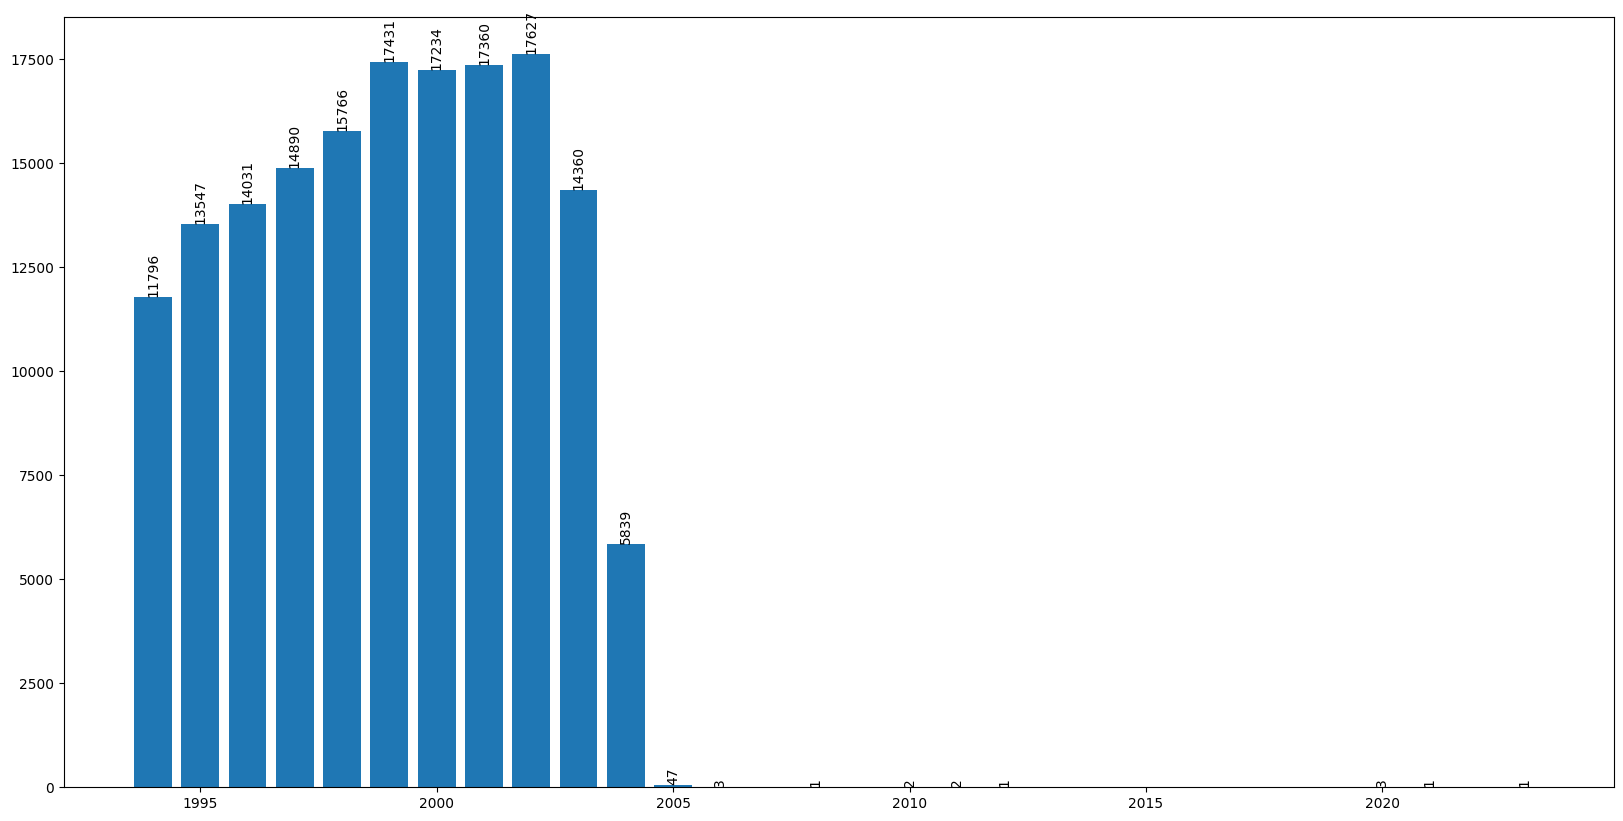

In [30]:
plt.figure(figsize=(20,10))
bars = plt.bar(x=books_year_rational.index,height=books_year_rational.values)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             '{:.0f}'.format(height), ha='center', va='bottom', rotation='vertical')
plt.show()

## Authors
Lets find out if there authors with multiple books or not

In [31]:
books[books['Book-Author'].duplicated()]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
62,0679865691,Haveli (Laurel Leaf Books),SUZANNE FISHER STAPLES,1995,Laurel Leaf,http://images.amazon.com/images/P/0679865691.0...,http://images.amazon.com/images/P/0679865691.0...,http://images.amazon.com/images/P/0679865691.0...
67,0804106304,The Joy Luck Club,Amy Tan,1994,Prentice Hall (K-12),http://images.amazon.com/images/P/0804106304.0...,http://images.amazon.com/images/P/0804106304.0...,http://images.amazon.com/images/P/0804106304.0...
74,0345465083,Seabiscuit,LAURA HILLENBRAND,2003,Ballantine Books,http://images.amazon.com/images/P/0345465083.0...,http://images.amazon.com/images/P/0345465083.0...,http://images.amazon.com/images/P/0345465083.0...
92,8445071769,El Senor De Los Anillos: Las DOS Torres (Lord ...,J. R. R. Tolkien,2001,Minotauro,http://images.amazon.com/images/P/8445071769.0...,http://images.amazon.com/images/P/8445071769.0...,http://images.amazon.com/images/P/8445071769.0...
93,8445071777,El Senor De Los Anillos: El Retorno Del Rey (T...,J. R. R. Tolkien,2001,Distribooks,http://images.amazon.com/images/P/8445071777.0...,http://images.amazon.com/images/P/8445071777.0...,http://images.amazon.com/images/P/8445071777.0...
...,...,...,...,...,...,...,...,...
271353,014002803X,Anti Death League,Kingsley Amis,1975,Viking Press,http://images.amazon.com/images/P/014002803X.0...,http://images.amazon.com/images/P/014002803X.0...,http://images.amazon.com/images/P/014002803X.0...
271354,0449906736,Flashpoints: Promise and Peril in a New World,Robin Wright,1993,Ballantine Books,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...
271355,0440400988,There's a Bat in Bunk Five,Paula Danziger,1988,Random House Childrens Pub (Mm),http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...,http://images.amazon.com/images/P/0440400988.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...


Lets find their number of books per author

In [32]:
# Number of unique authors
len(books['Book-Author'].unique())

102022

In [33]:
author_book_count = books['Book-Author'].value_counts()
author_book_count.head(20)

Book-Author
Agatha Christie          632
William Shakespeare      567
Stephen King             524
Ann M. Martin            423
Carolyn Keene            373
Francine Pascal          372
Isaac Asimov             330
Nora Roberts             315
Barbara Cartland         307
Charles Dickens          302
Not Applicable (Na )     286
R. L. Stine              282
Mark Twain               231
Jane Austen              223
Terry Pratchett          220
Mary Higgins Clark       218
Piers Anthony            217
Marion Zimmer Bradley    216
Janet Dailey             214
Franklin W. Dixon        204
Name: count, dtype: int64

### Error in author name:
Looks like there are a lot of books with no authors. So lets drop them for a while and count the rest

In [34]:
author_book_count = books[books['Book-Author']!= 'Not Applicable (Na )']
author_book_count_top50 = author_book_count.groupby('Book-Author').count()['Book-Title'].sort_values(ascending=False).head(50)
author_book_count_top50.head(10)

Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: Book-Title, dtype: int64

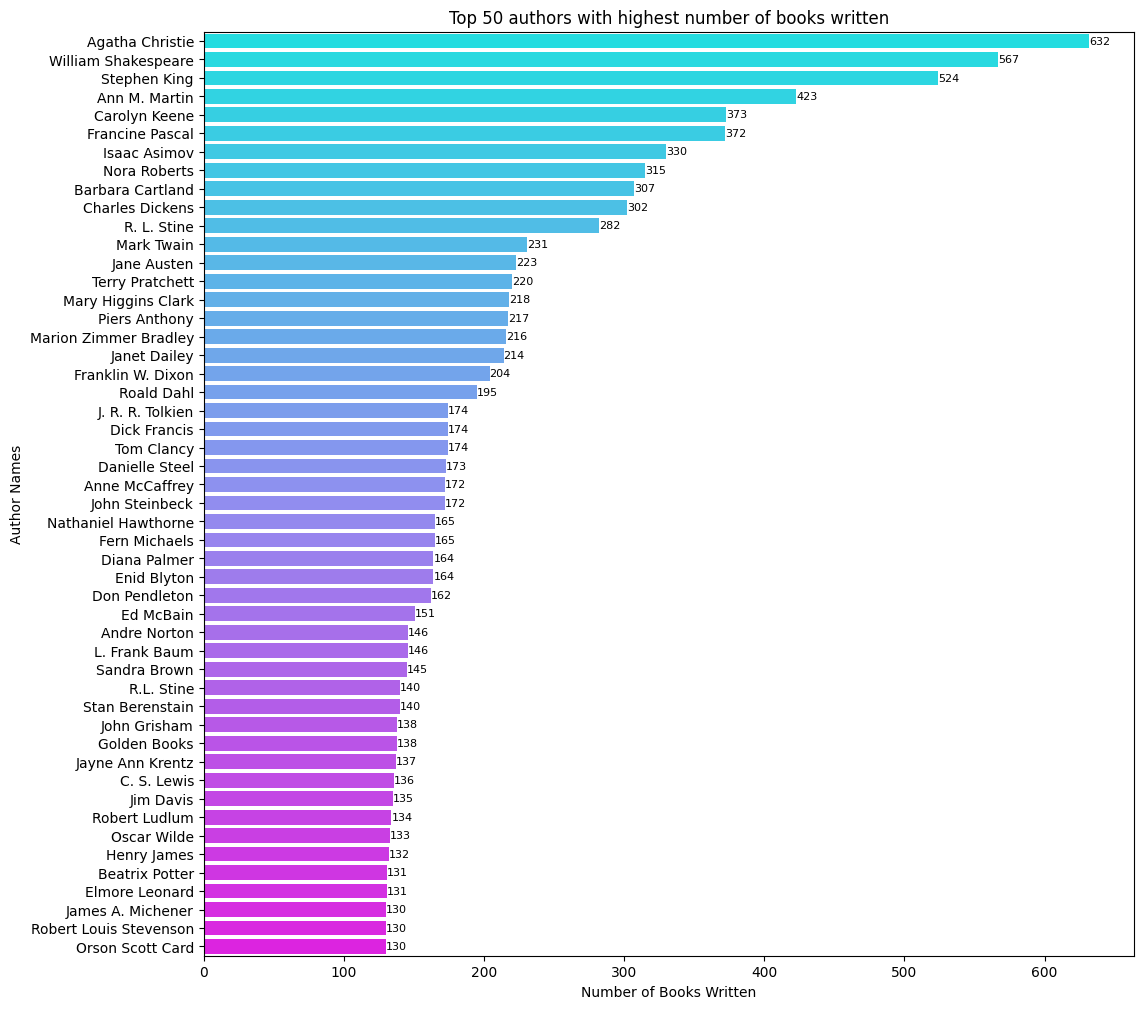

In [35]:
cool = sns.color_palette("cool", n_colors=len(author_book_count_top50.values))

plt.figure(figsize=(12, 12))

sns_plot = sns.barplot(y=author_book_count_top50.index,
                       x=author_book_count_top50.values, palette=cool, hue=cool, legend=False, orient='h')

for i, value in enumerate(author_book_count_top50.values):
    sns_plot.text(value, i, int(value), ha="left",
                  va="center", color='black', fontsize=8)

plt.ylabel("Author Names")
plt.xlabel("Number of Books Written")
plt.title("Top 50 authors with highest number of books written")
plt.show()

In [36]:
publishers = books['Publisher'].value_counts()
publishers

Publisher
Harlequin                                                    7535
Silhouette                                                   4220
Pocket                                                       3905
Ballantine Books                                             3783
Bantam Books                                                 3646
                                                             ... 
Flemish-Netherlands Foundation \Stichting Ons Erfdeel,\""       1
Drew Marketing &amp; Productions                                1
Demeter Press                                                   1
Znanje                                                          1
Michael Omara Books Ltd                                         1
Name: count, Length: 16804, dtype: int64

In [37]:
top_50_publishers = publishers.sort_values(ascending=False)[:51]
top_50_publishers

Publisher
Harlequin                             7535
Silhouette                            4220
Pocket                                3905
Ballantine Books                      3783
Bantam Books                          3646
Scholastic                            3160
Simon &amp; Schuster                  2971
Penguin Books                         2844
Berkley Publishing Group              2771
Warner Books                          2727
Penguin USA                           2717
Harpercollins                         2525
Fawcett Books                         2258
Signet Book                           2070
Random House Inc                      2045
St Martins Pr                         1953
St. Martin's Press                    1783
Tor Books                             1704
HarperCollins Publishers              1700
Zebra Books                           1694
Bantam                                1660
Avon                                  1566
Jove Books                            1553
V

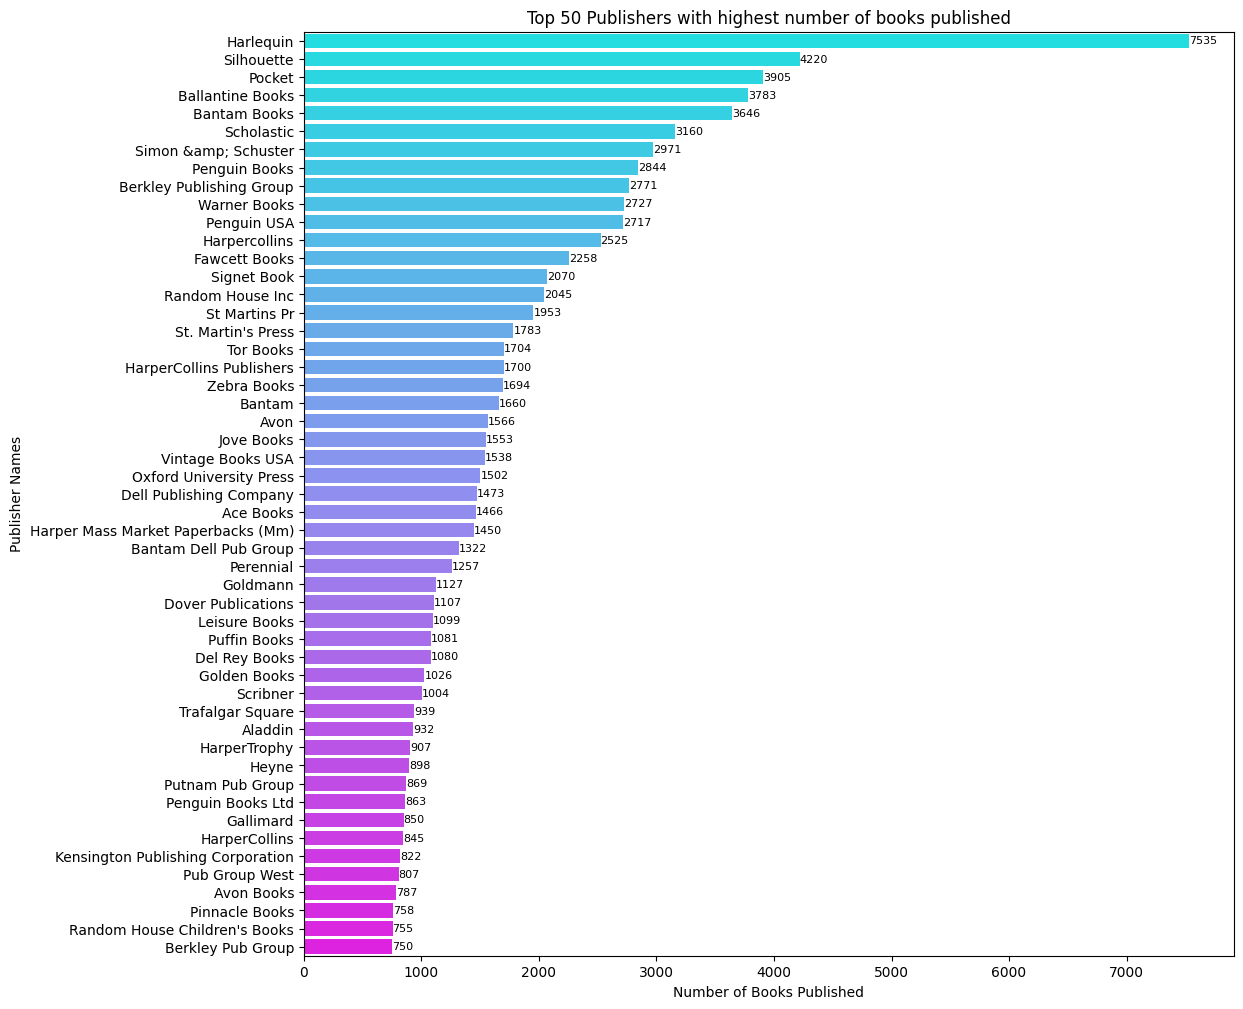

In [38]:
cool = sns.color_palette("cool", n_colors=len(top_50_publishers.values))

plt.figure(figsize=(12, 12))

sns_plot = sns.barplot(y=top_50_publishers.index,
                       x=top_50_publishers.values, palette=cool, hue=cool, legend=False, orient='h')

for i, value in enumerate(top_50_publishers.values):
    sns_plot.text(value, i, int(value), ha="left",
                  va="center", color='black', fontsize=8)
                  

plt.ylabel("Publisher Names")
plt.xlabel("Number of Books Published")
plt.title("Top 50 Publishers with highest number of books published")
plt.show()

# Ratings Dataset
We have two columns in the ratings dataset with columns: ISBN and rating along with user-ID
Since, it is difficult to identify books based on ISBN, we merge the datasets **Books** and **Ratings** on the ISBN column

In [39]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [40]:
display(books.shape)
display(ratings.shape)

(271360, 8)

(1149780, 3)

In [41]:
bookRating = pd.merge(ratings, books, on="ISBN")
bookRating.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


In [42]:
bookRating.shape

(1031136, 10)

### Calculating the Average Rating of all Books

In [43]:
averageRating = pd.DataFrame(bookRating.groupby('ISBN')['Book-Rating'].mean().round(1))
averageRating.reset_index(inplace=True)
averageRating.head()

,ISBN,Book-Rating
0,0000913154,8.0
1,0001010565,0.0
2,0001046438,9.0
3,0001046713,0.0
4,000104687X,6.0


In [44]:
averageRating.shape
averageRating.rename(columns={'Book-Rating':'Average-Rating'}, inplace=True)
averageRating.head()

,ISBN,Average-Rating
0,0000913154,8.0
1,0001010565,0.0
2,0001046438,9.0
3,0001046713,0.0
4,000104687X,6.0


In [45]:
averageRatingdf = pd.merge(bookRating, averageRating, on='ISBN')
averageRatingdf.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Average-Rating
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,2.9
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,2.5
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,4.1
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,3.0
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,6.0


In [46]:
averageRatingdf.shape

(1031136, 11)

In [47]:
averageRatingOnly = averageRatingdf[['ISBN','Average-Rating']]
averageRatingOnly.head()

,ISBN,Average-Rating
0,034545104X,2.9
1,0155061224,2.5
2,0446520802,4.1
3,052165615X,3.0
4,0521795028,6.0


In [48]:
averageRatingUnique = averageRatingOnly[['ISBN','Average-Rating']].drop_duplicates(subset=['ISBN'])
averageRatingUnique.head()

,ISBN,Average-Rating
0,034545104X,2.9
1,0155061224,2.5
2,0446520802,4.1
3,052165615X,3.0
4,0521795028,6.0


In [49]:
ratingBooks = pd.merge(books, averageRatingUnique, on='ISBN', how='inner')

In [50]:
display(books.shape)
averageRatingUnique.shape

(271360, 8)

(270151, 2)

In [51]:
books_with_rating = pd.merge(books, averageRatingUnique, on='ISBN')
books_with_rating.shape

(270151, 9)

In [52]:
books_with_rating = books_with_rating[['ISBN','Book-Title','Book-Author','Average-Rating','Year-Of-Publication','Publisher','Image-URL-S','Image-URL-M','Image-URL-L']]
books_with_rating.head()

,ISBN,Book-Title,Book-Author,Average-Rating,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,0.0,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,4.9,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,5.0,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,4.3,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,0.0,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


### EDA on Average Rating of Book
Viewing the top 30 books with highest average rating

In [53]:
books_with_rating.sort_values(by=['Average-Rating'], ascending=False).head(30)

,ISBN,Book-Title,Book-Author,Average-Rating,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
270138,0395264707,Dreamsnake,Vonda N. McIntyre,10.0,1978,Houghton Mifflin,http://images.amazon.com/images/P/0395264707.0...,http://images.amazon.com/images/P/0395264707.0...,http://images.amazon.com/images/P/0395264707.0...
77197,0312861605,The Dragon and the Fair Maid of Kent,Gordon R. Dickson,10.0,2000,Tor Books,http://images.amazon.com/images/P/0312861605.0...,http://images.amazon.com/images/P/0312861605.0...,http://images.amazon.com/images/P/0312861605.0...
77210,1582460507,First Book of Sushi (World Snacks),Amy Wilson Sanger,10.0,2001,Tricycle Press,http://images.amazon.com/images/P/1582460507.0...,http://images.amazon.com/images/P/1582460507.0...,http://images.amazon.com/images/P/1582460507.0...
77211,1402708610,I Know a Rhino,Charles Fuge,10.0,2003,Sterling,http://images.amazon.com/images/P/1402708610.0...,http://images.amazon.com/images/P/1402708610.0...,http://images.amazon.com/images/P/1402708610.0...
77213,1553690257,An Ia Story: One Thread in the Tapestry of Con...,S. A. Stanley,10.0,2002,Not Avail,http://images.amazon.com/images/P/1553690257.0...,http://images.amazon.com/images/P/1553690257.0...,http://images.amazon.com/images/P/1553690257.0...
77217,1591132177,Outcast,Michael Woods,10.0,2002,Booklocker.com,http://images.amazon.com/images/P/1591132177.0...,http://images.amazon.com/images/P/1591132177.0...,http://images.amazon.com/images/P/1591132177.0...
77220,0413743802,The Hunting of the Snark: An Agony in Eight Fits,Lewis Carroll,10.0,2002,Methuen,http://images.amazon.com/images/P/0413743802.0...,http://images.amazon.com/images/P/0413743802.0...,http://images.amazon.com/images/P/0413743802.0...
270089,1584855096,Amelia's School Survival Guide (Amelia),Marissa Moss,10.0,2002,Pleasant Company Publications,http://images.amazon.com/images/P/1584855096.0...,http://images.amazon.com/images/P/1584855096.0...,http://images.amazon.com/images/P/1584855096.0...
270092,1584857447,True Stories: Girls' Inspiring Stories of Cour...,Trula Magruder,10.0,2003,American Girl,http://images.amazon.com/images/P/1584857447.0...,http://images.amazon.com/images/P/1584857447.0...,http://images.amazon.com/images/P/1584857447.0...
270093,1893699056,"Mayhem on Mackinac Island (Michigan Chillers, 1)",Johnathan Rand,10.0,2000,Audio Craft Press,http://images.amazon.com/images/P/1893699056.0...,http://images.amazon.com/images/P/1893699056.0...,http://images.amazon.com/images/P/1893699056.0...


In [54]:
ratings_sorted = books_with_rating['Average-Rating'].value_counts().sort_index(ascending=False)
display(ratings_sorted)
books_with_rating['Average-Rating'].value_counts(normalize=True).round(4).sort_index(ascending=False)

Average-Rating
10.0     13112
9.8         14
9.7         48
9.6          2
9.5        489
         ...  
0.4        124
0.3        102
0.2         49
0.1         12
0.0     120315
Name: count, Length: 100, dtype: int64

Average-Rating
10.0    0.0485
9.8     0.0001
9.7     0.0002
9.6     0.0000
9.5     0.0018
         ...  
0.4     0.0005
0.3     0.0004
0.2     0.0002
0.1     0.0000
0.0     0.4454
Name: proportion, Length: 100, dtype: float64

/tmp/ipykernel_119793/2193251816.py:4: UserWarning: The palette list has more values (100) than needed (99), which may not be intended.
  sns_plot = sns.barplot(


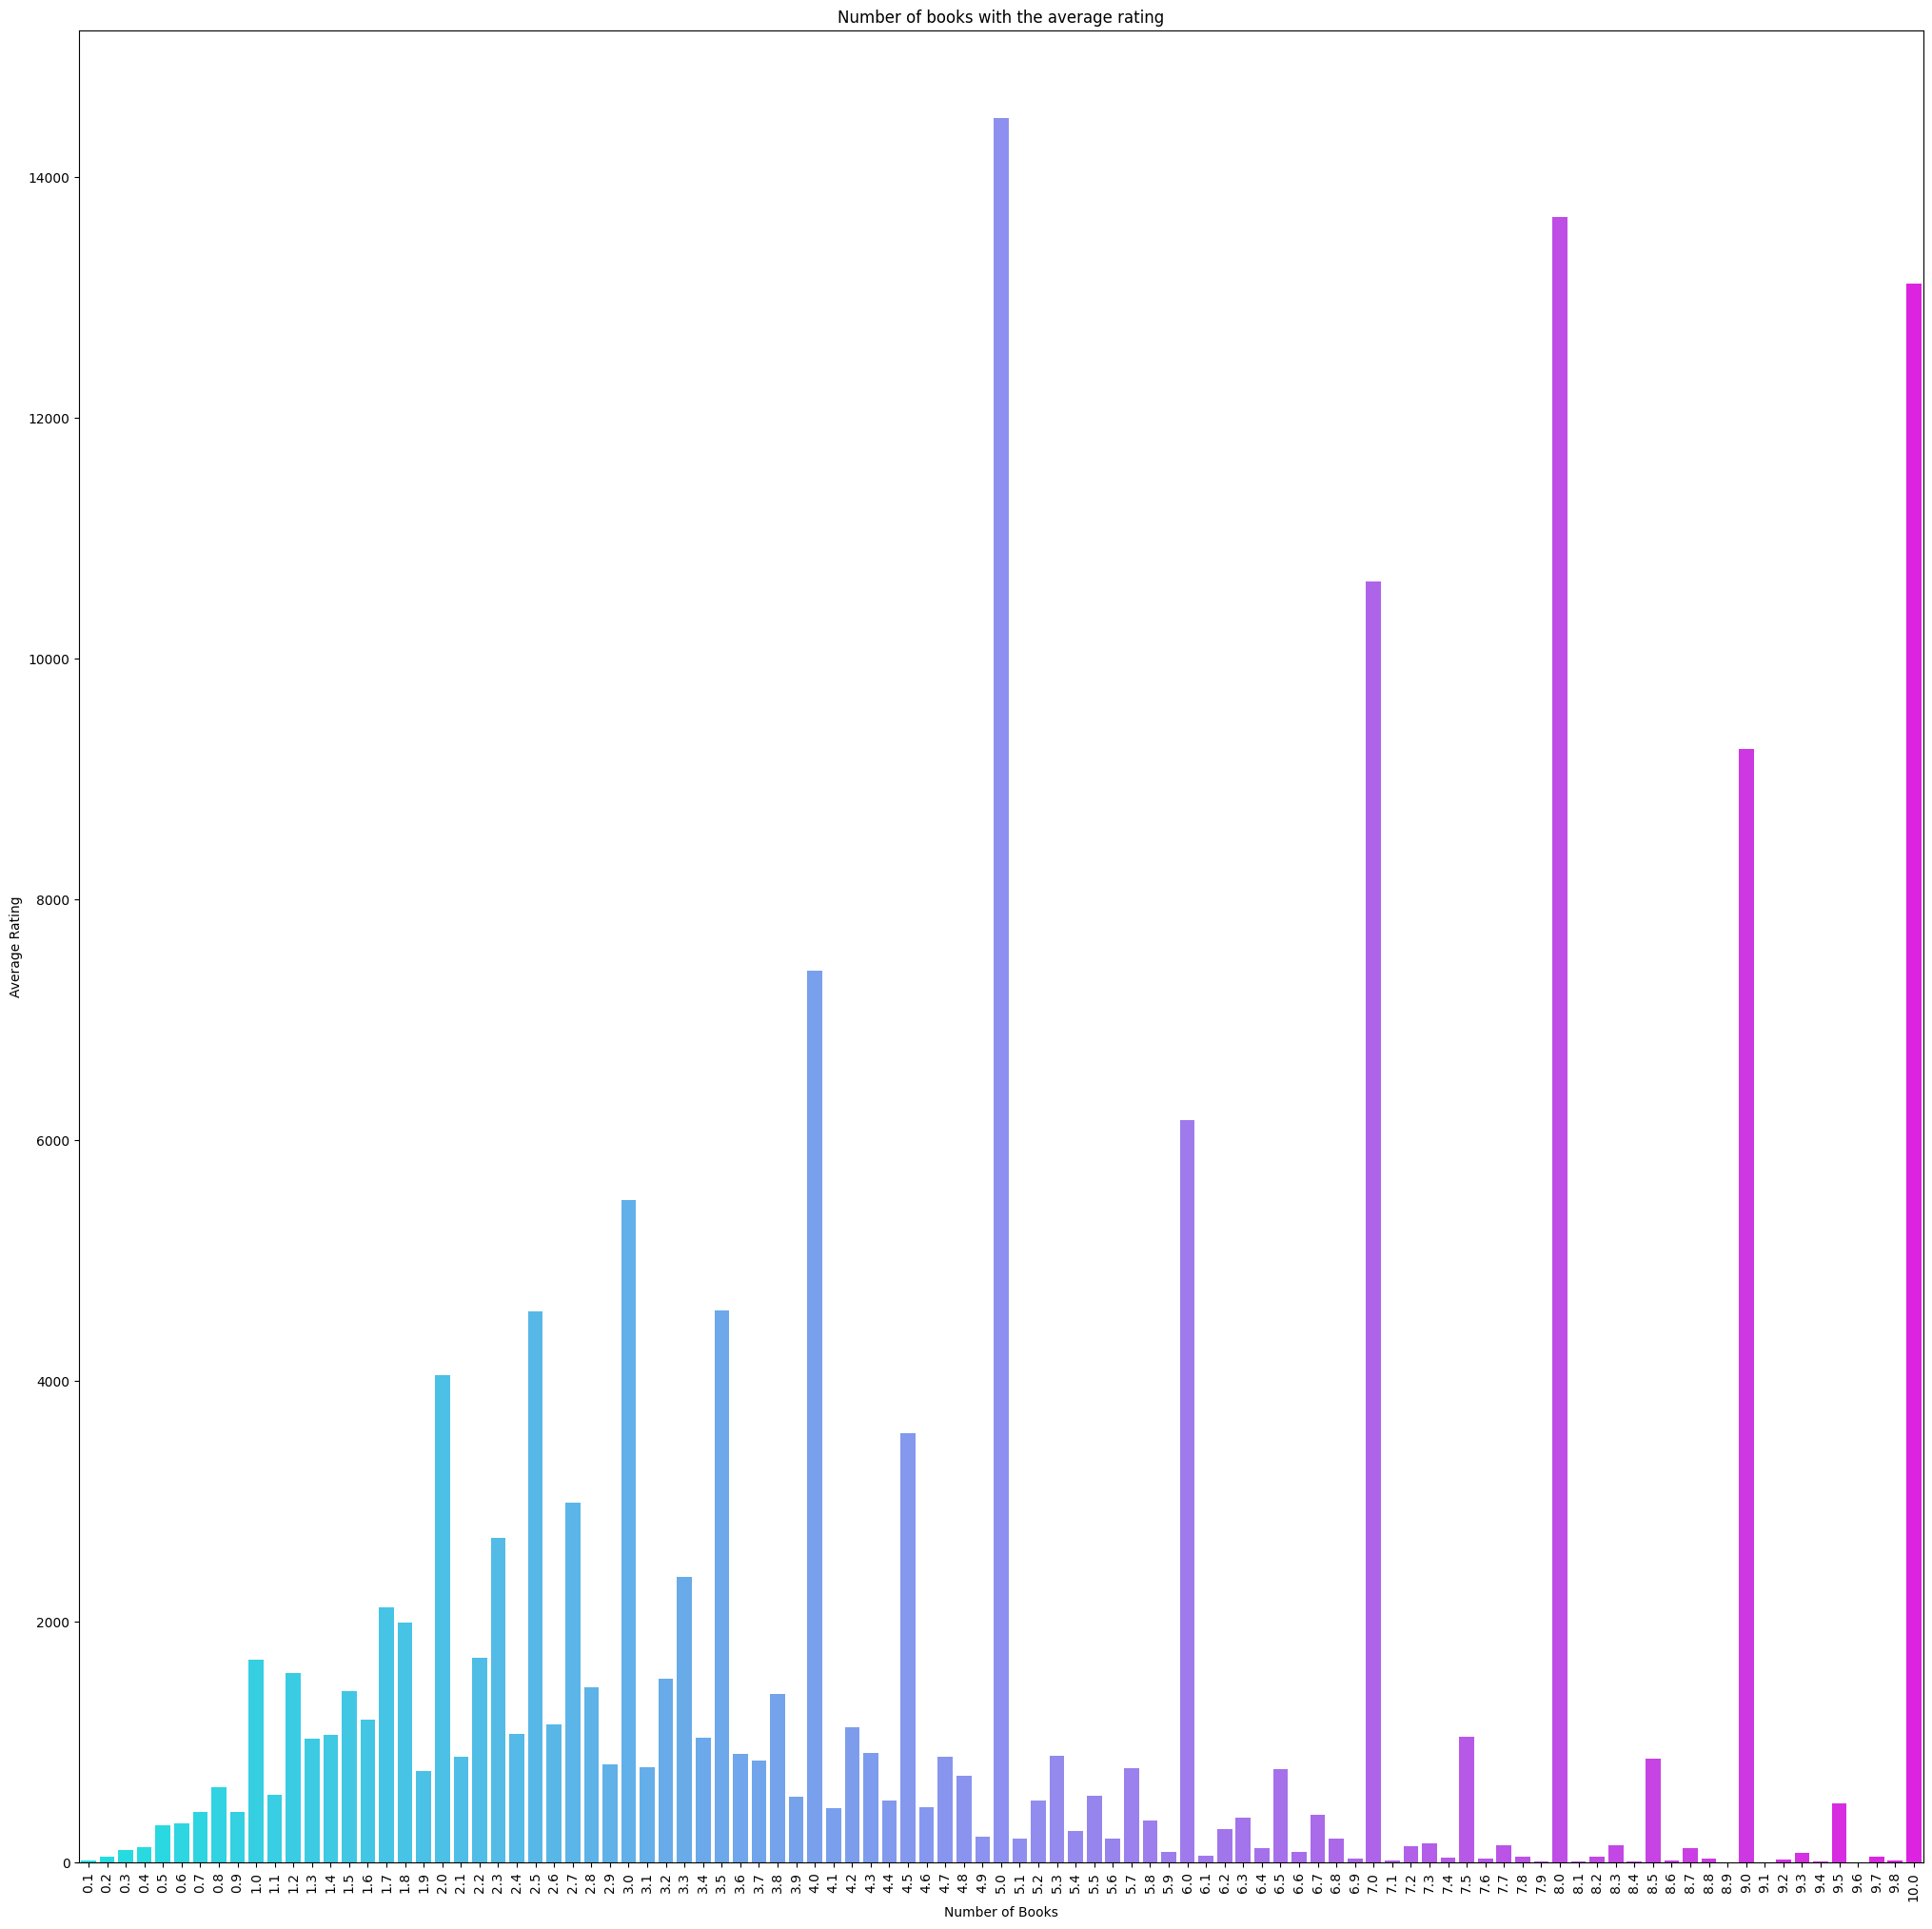

In [55]:
cool = sns.color_palette("cool", n_colors=len(ratings_sorted.values))
plt.figure(figsize=(25,25))
ratings_sorted_0_excluded = ratings_sorted.drop(index=0.0).sort_index(ascending=False)
sns_plot = sns.barplot(
    x=ratings_sorted_0_excluded.index,
    y=ratings_sorted_0_excluded.values,
    hue=ratings_sorted_0_excluded.index,
    palette=cool,
    legend=False
)
plt.xticks(rotation='vertical')
plt.xlabel("Number of Books")
plt.ylabel('Average Rating')
plt.title("Number of books with the average rating")
plt.show()

In [56]:
top_20_ratings = books_with_rating['Average-Rating'].value_counts().drop(index=0.0).sort_values(ascending=False).head(20)

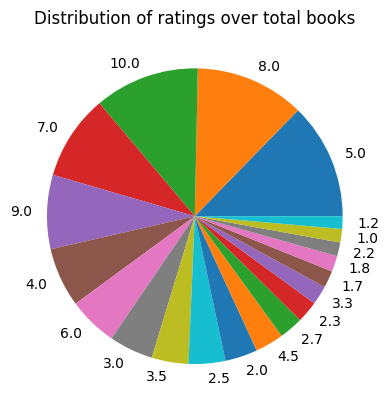

In [57]:
plt.pie(top_20_ratings, labels=top_20_ratings.index)
plt.title("Distribution of ratings over total books")
plt.show()

### Data Visualization results
We can see the most rated books are **5**,**8**, and **10**

In [58]:
display(users.shape)
users.head()

(278858, 2)

,User-ID,Location
0,1,"nyc, new york, usa"
1,2,"stockton, california, usa"
2,3,"moscow, yukon territory, russia"
3,4,"porto, v.n.gaia, portugal"
4,5,"farnborough, hants, united kingdom"


In [59]:
len(users.Location.unique())

57339

In [60]:
users.Location.value_counts()

Location
london, england, united kingdom              2506
toronto, ontario, canada                     2250
sydney, new south wales, australia           1744
melbourne, victoria, australia               1708
portland, oregon, usa                        1629
                                             ... 
new lothrop, michigan, usa                      1
esplugas de llobregat, n/a, spain               1
baxter springs, kansas, usa                     1
gustow, mecklenburg-vorpommern, germany         1
san colombano al lambro, lombardia, italy       1
Name: count, Length: 57339, dtype: int64

### MACHINE LEARNING AND BUILDING A MODEL

We would be making and deploying a ML algorithm for book recommendation system.

### Popularity Based Recommender System
We would select the top 50 books that have the highest average ratings and then display them over to the user. <br> But the problem with this system is that if some book has low number of votes but high rating then it could get biased and proportionally incorrect.<br>So, inorder to avoid that we will set a criteria where we only select the average ratings of books that have been voted by at least **100 users**.

In [61]:
ratings_books_merged = ratings.merge(books, on='ISBN')
display(ratings_books_merged.head())
ratings_books_merged.shape

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


(1031136, 10)

### Number of Votes
Lets count the number of votes for each book
<br>

In [62]:
ratings_books_nonzero = ratings_books_merged[ratings_books_merged['Book-Rating']!=0]
num_rating_df = ratings_books_nonzero.groupby('Book-Title').count()['Book-Rating'].sort_values(ascending=False).reset_index()
num_rating_df.rename(columns={'Book-Rating':'Number-of-Ratings'}, inplace=True)
display(num_rating_df)

,Book-Title,Number-of-Ratings
0,The Lovely Bones: A Novel,707
1,Wild Animus,581
2,The Da Vinci Code,494
3,The Secret Life of Bees,406
4,The Nanny Diaries: A Novel,393
...,...,...
135562,Ã?rsringen: Roman,1
135563,Ã?ngeles fugaces (Falling Angels),1
135564,Ã?kotopia: Notizen und Reportagen von William ...,1
135565,Ã?ber den physiologischen Stumpfsinn des Manne...,1


### Average Book Rating
Lets find the average ratings of books

In [63]:
avg_rating_df = ratings_books_nonzero.groupby('Book-Title').mean(numeric_only=True)['Book-Rating'].reset_index()
avg_rating_df.rename(columns={'Book-Rating':'Average-Rating'}, inplace=True)
avg_rating_df.head()

,Book-Title,Average-Rating
0,A Light in the Storm: The Civil War Diary of ...,9.000000
1,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
2,Dark Justice,10.000000
3,Earth Prayers From around the World: 365 Pray...,7.142857
4,Final Fantasy Anthology: Official Strategy Gu...,10.000000


Merging these two dataframes

In [64]:
popularity_df = pd.merge(num_rating_df, avg_rating_df, on='Book-Title')
popularity_df

,Book-Title,Number-of-Ratings,Average-Rating
0,The Lovely Bones: A Novel,707,8.185290
1,Wild Animus,581,4.390706
2,The Da Vinci Code,494,8.439271
3,The Secret Life of Bees,406,8.477833
4,The Nanny Diaries: A Novel,393,7.437659
...,...,...,...
135562,Ã?rsringen: Roman,1,3.000000
135563,Ã?ngeles fugaces (Falling Angels),1,4.000000
135564,Ã?kotopia: Notizen und Reportagen von William ...,1,4.000000
135565,Ã?ber den physiologischen Stumpfsinn des Manne...,1,8.000000


Taking the books whose number of ratings are greater than 100

In [65]:
popularity_df_above_100 = popularity_df[popularity_df['Number-of-Ratings']>=100]
popularity_df_above_50 = popularity_df[popularity_df['Number-of-Ratings'] >= 50]
popularity_df_above_250 = popularity_df[popularity_df['Number-of-Ratings'] >= 250]
popularity_df_above_100.sort_values(by='Average-Rating', ascending=False).head()

,Book-Title,Number-of-Ratings,Average-Rating
114,"The Two Towers (The Lord of the Rings, Part 2)",136,9.330882
179,"The Return of the King (The Lord of the Rings,...",103,9.213592
28,Harry Potter and the Goblet of Fire (Book 4),247,9.125506
68,Harry Potter and the Sorcerer's Stone (Book 1),176,9.062500
42,Harry Potter and the Order of the Phoenix (Boo...,211,9.047393


### New metric for rating calculation
We still have a problem if there are low number of high ratings, and high number of lower ratings, we get a bias and unfairness in the rating scenario.
<br>
To tackle this, lets use a new metric known as weighted metric which can be calculated by:


weighted_rating = (average_rating * number_of_ratings + minimum_threshold * default_rating)/(number_of_ratings + minimum_threshold)
<br><br>
where,<br><br>
**average_rating** is available from dataframe<br>
**number_of_ratings** is available from dataframe<br>
**minimum_threshold** is the minimum number of votes taken for validation. Here, **100** <br>
**default_rating** is the neutral state. Here, **5.0** <br>

In [66]:
# Defining a new function that can calculate the metric
def calcWeightedRating(row, avgRating, numOfRatings, minThres, defRating):
    weightedRating = ((row[avgRating] * row[numOfRatings]) + (minThres * defRating))/(row[numOfRatings] + minThres)
    return weightedRating

Great, lets apply this in our existing dataframe

In [67]:
# For number of ratings above 100
popularity_df_above_100 = popularity_df_above_100.copy()
popularity_df_above_100['Weighted-Rating'] = popularity_df_above_100.apply(lambda x: calcWeightedRating(
     x, 'Average-Rating', 'Number-of-Ratings', 100, 5),axis=1)
popularity_df_above_100.sort_values(
    'Weighted-Rating', ascending=False).head(20)

,Book-Title,Number-of-Ratings,Average-Rating,Weighted-Rating
11,Harry Potter and the Sorcerer's Stone (Harry P...,315,8.936508,7.987952
17,Harry Potter and the Prisoner of Azkaban (Book 3),277,9.043321,7.970822
9,Harry Potter and the Chamber of Secrets (Book 2),326,8.840491,7.938967
28,Harry Potter and the Goblet of Fire (Book 4),247,9.125506,7.936599
20,To Kill a Mockingbird,267,8.977528,7.893733
2,The Da Vinci Code,494,8.439271,7.860269
0,The Lovely Bones: A Novel,707,8.185290,7.790582
3,The Secret Life of Bees,406,8.477833,7.790514
42,Harry Potter and the Order of the Phoenix (Boo...,211,9.047393,7.745981
48,The Fellowship of the Ring (The Lord of the Ri...,205,8.882927,7.609836


In [68]:
# For number of ratings above 50
popularity_df_above_50 = popularity_df_above_50.copy()
popularity_df_above_50['Weighted-Rating'] = popularity_df_above_50.apply(lambda x: calcWeightedRating(
    x, 'Average-Rating', 'Number-of-Ratings', 50, 5), axis=1)
popularity_df_above_50.sort_values(
    'Weighted-Rating', ascending=False).head(20)

,Book-Title,Number-of-Ratings,Average-Rating,Weighted-Rating
28,Harry Potter and the Goblet of Fire (Book 4),247,9.125506,8.430976
17,Harry Potter and the Prisoner of Azkaban (Book 3),277,9.043321,8.425076
11,Harry Potter and the Sorcerer's Stone (Harry P...,315,8.936508,8.397260
20,To Kill a Mockingbird,267,8.977528,8.350158
9,Harry Potter and the Chamber of Secrets (Book 2),326,8.840491,8.329787
42,Harry Potter and the Order of the Phoenix (Boo...,211,9.047393,8.272031
114,"The Two Towers (The Lord of the Rings, Part 2)",136,9.330882,8.166667
68,Harry Potter and the Sorcerer's Stone (Book 1),176,9.062500,8.163717
2,The Da Vinci Code,494,8.439271,8.123162
48,The Fellowship of the Ring (The Lord of the Ri...,205,8.882927,8.121569


In [69]:
# For number of ratings above 250
popularity_df_above_250 = popularity_df_above_250.copy()
popularity_df_above_250['Weighted-Rating'] = popularity_df_above_250.apply(lambda x: calcWeightedRating(
    x, 'Average-Rating', 'Number-of-Ratings', 250, 5), axis=1)
popularity_df_above_250.sort_values(
    'Weighted-Rating', ascending=False).head(20)

,Book-Title,Number-of-Ratings,Average-Rating,Weighted-Rating
0,The Lovely Bones: A Novel,707,8.185290,7.353187
2,The Da Vinci Code,494,8.439271,7.283602
11,Harry Potter and the Sorcerer's Stone (Harry P...,315,8.936508,7.194690
9,Harry Potter and the Chamber of Secrets (Book 2),326,8.840491,7.173611
3,The Secret Life of Bees,406,8.477833,7.152439
17,Harry Potter and the Prisoner of Azkaban (Book 3),277,9.043321,7.125237
20,To Kill a Mockingbird,267,8.977528,7.054159
5,The Red Tent (Bestselling Backlist),383,8.182768,6.925750
26,"Tuesdays with Morrie: An Old Man, a Young Man,...",250,8.588000,6.794000
8,Life of Pi,336,8.080357,6.766212


### Merging with the books dataframe
We merge the popularity_df_above_250 with books dataframe to get the information about the book author and other details.

In [70]:
popular_df_merge = pd.merge(popularity_df_above_100, books, on='Book-Title').drop_duplicates('Book-Title',keep='first')
popular_df_merge = popular_df_merge.drop(columns=['Image-URL-S', 'Image-URL-L'])
display(popular_df_merge.shape)
popular_df_merge.sort_values('Weighted-Rating', ascending=False).head(10)

(200, 9)

,Book-Title,Number-of-Ratings,Average-Rating,Weighted-Rating,ISBN,Book-Author,Year-Of-Publication,Publisher,Image-URL-M
38,Harry Potter and the Sorcerer's Stone (Harry P...,315,8.936508,7.987952,059035342X,J. K. Rowling,1999,Arthur A. Levine Books,http://images.amazon.com/images/P/059035342X.0...
56,Harry Potter and the Prisoner of Azkaban (Book 3),277,9.043321,7.970822,0439136350,J. K. Rowling,1999,Scholastic,http://images.amazon.com/images/P/0439136350.0...
32,Harry Potter and the Chamber of Secrets (Book 2),326,8.840491,7.938967,0439064872,J. K. Rowling,2000,Scholastic,http://images.amazon.com/images/P/0439064872.0...
109,Harry Potter and the Goblet of Fire (Book 4),247,9.125506,7.936599,0439139597,J. K. Rowling,2000,Scholastic,http://images.amazon.com/images/P/0439139597.0...
67,To Kill a Mockingbird,267,8.977528,7.893733,0446310786,Harper Lee,1988,Little Brown &amp; Company,http://images.amazon.com/images/P/0446310786.0...
2,The Da Vinci Code,494,8.439271,7.860269,0385504209,Dan Brown,2003,Doubleday,http://images.amazon.com/images/P/0385504209.0...
0,The Lovely Bones: A Novel,707,8.185290,7.790582,0316666343,Alice Sebold,2002,"Little, Brown",http://images.amazon.com/images/P/0316666343.0...
8,The Secret Life of Bees,406,8.477833,7.790514,0142001740,Sue Monk Kidd,2003,Penguin Books,http://images.amazon.com/images/P/0142001740.0...
167,Harry Potter and the Order of the Phoenix (Boo...,211,9.047393,7.745981,043935806X,J. K. Rowling,2003,Scholastic,http://images.amazon.com/images/P/043935806X.0...
189,The Fellowship of the Ring (The Lord of the Ri...,205,8.882927,7.609836,0345339703,J.R.R. TOLKIEN,1986,Del Rey,http://images.amazon.com/images/P/0345339703.0...


### TOP RATED BOOKS
The books shown above are the top rated books and could be shown in the home page of the app

#### Collaborative Filtering Based Approach
For user based recommendation system, we build a new type of data like:

Where each user would have rating for each book and we would also follow criterias like:

1. **Value experienced users ratings:**
    
    We would take the ratings of the users who have rated over 200 books i.e. have studied and reviewed high amount of books with the highest priority.
    
2. **Value books with high ratings:**
    
    We would only recommend books that have more than 50 ratings i.e. popular and famous books.

In [71]:
ratings_books_merged.head()

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


#### Filtering Users
Let's find users who have made at least 200 votes.

In [72]:
users_ratings_count = ratings_books_merged.groupby('User-ID').count()['ISBN']
users_ratings_count = users_ratings_count.sort_values(ascending=False).reset_index()
users_ratings_count.rename(columns={'ISBN':'No-of-Books-Rated'}, inplace=True)
display(users_ratings_count.shape)
users_ratings_count.head()

(92106, 2)

,User-ID,No-of-Books-Rated
0,11676,11144
1,198711,6456
2,153662,5814
3,98391,5779
4,35859,5646


There are 92106 users who have rated the books.

In [73]:
users_200 = users_ratings_count[users_ratings_count['No-of-Books-Rated']>=200]
display(users_200.shape)

(816, 2)

There are only 816 users who have rated more than 200 times

In [74]:
books_with_users_200 = pd.merge(users_200, ratings_books_merged, on='User-ID')
display(books_with_users_200.shape)
books_with_users_200.head()

(475007, 11)

,User-ID,No-of-Books-Rated,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,11676,11144,0001837397,0,Autumn Story Brambly Hedge,Jill Barklem,0,William Collins Sons Co Ltd,http://images.amazon.com/images/P/0001837397.0...,http://images.amazon.com/images/P/0001837397.0...,http://images.amazon.com/images/P/0001837397.0...
1,11676,11144,0001841572,0,Red Shift,Alan Garner,1973,Collins,http://images.amazon.com/images/P/0001841572.0...,http://images.amazon.com/images/P/0001841572.0...,http://images.amazon.com/images/P/0001841572.0...
2,11676,11144,0001848445,0,THE COAL HOUSE T/PB,Andrew Taylor,1986,HarperCollins Publishers,http://images.amazon.com/images/P/0001848445.0...,http://images.amazon.com/images/P/0001848445.0...,http://images.amazon.com/images/P/0001848445.0...
3,11676,11144,0001900277,0,Glue (First Facts - First Skills),Harriet Hains,1989,HarperCollins Publishers,http://images.amazon.com/images/P/0001900277.0...,http://images.amazon.com/images/P/0001900277.0...,http://images.amazon.com/images/P/0001900277.0...
4,11676,11144,0001941941,0,Little Grey Rabbit's Christmas (Collins Colour...,Alison Uttley,1978,HarperCollins Publishers,http://images.amazon.com/images/P/0001941941.0...,http://images.amazon.com/images/P/0001941941.0...,http://images.amazon.com/images/P/0001941941.0...


In [75]:
books[books['Year-Of-Publication'] == 0].head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
176,3150000335,Kabale Und Liebe,Schiller,0,"Philipp Reclam, Jun Verlag GmbH",http://images.amazon.com/images/P/3150000335.0...,http://images.amazon.com/images/P/3150000335.0...,http://images.amazon.com/images/P/3150000335.0...
188,342311360X,Die Liebe in Den Zelten,Gabriel Garcia Marquez,0,Deutscher Taschenbuch Verlag (DTV),http://images.amazon.com/images/P/342311360X.0...,http://images.amazon.com/images/P/342311360X.0...,http://images.amazon.com/images/P/342311360X.0...
288,0571197639,Poisonwood Bible Edition Uk,Barbara Kingsolver,0,Faber Faber Inc,http://images.amazon.com/images/P/0571197639.0...,http://images.amazon.com/images/P/0571197639.0...,http://images.amazon.com/images/P/0571197639.0...
351,3596214629,"Herr Der Fliegen (Fiction, Poetry and Drama)",Golding,0,Fischer Taschenbuch Verlag GmbH,http://images.amazon.com/images/P/3596214629.0...,http://images.amazon.com/images/P/3596214629.0...,http://images.amazon.com/images/P/3596214629.0...
542,8845229041,Biblioteca Universale Rizzoli: Sulla Sponda De...,P Coelho,0,Fabbri - RCS Libri,http://images.amazon.com/images/P/8845229041.0...,http://images.amazon.com/images/P/8845229041.0...,http://images.amazon.com/images/P/8845229041.0...


In [76]:
books.loc[176, 'Year-Of-Publication'] = 1784

In [77]:
books.loc[188, 'Year-Of-Publication'] = 1991

books.loc[288, 'Year-Of-Publication'] = 1999

books.loc[351, 'Year-Of-Publication'] = 1954

books.loc[542, 'Year-Of-Publication'] = 1996

In [78]:
books[books['Year-Of-Publication'] == 0]

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
641,0345251733,Rainbow the Stormy Life of Judy Garland,Christopher Finch,0,Ballantine Books,http://images.amazon.com/images/P/0345251733.0...,http://images.amazon.com/images/P/0345251733.0...,http://images.amazon.com/images/P/0345251733.0...
646,0590021117,Little House On the Prairie,Laura Ingall Wilder,0,Scholastic Inc,http://images.amazon.com/images/P/0590021117.0...,http://images.amazon.com/images/P/0590021117.0...,http://images.amazon.com/images/P/0590021117.0...
728,2070362388,Ravage,Rene Barjavel,0,Gallimard French,http://images.amazon.com/images/P/2070362388.0...,http://images.amazon.com/images/P/2070362388.0...,http://images.amazon.com/images/P/2070362388.0...
732,2266033689,Le Diable Au Corps,Raymond Radiguet,0,Presses Pocket French,http://images.amazon.com/images/P/2266033689.0...,http://images.amazon.com/images/P/2266033689.0...,http://images.amazon.com/images/P/2266033689.0...
735,2070334368,La Guerre Des Boutons,Pergaud,0,Livre de Poche,http://images.amazon.com/images/P/2070334368.0...,http://images.amazon.com/images/P/2070334368.0...,http://images.amazon.com/images/P/2070334368.0...
...,...,...,...,...,...,...,...,...
270794,014029953X,Foe (Essential.penguin S.),J.M. Coetzee,0,Penguin Books Ltd,http://images.amazon.com/images/P/014029953X.0...,http://images.amazon.com/images/P/014029953X.0...,http://images.amazon.com/images/P/014029953X.0...
270913,0340571187,Postmens House,Maggie Hemingway,0,Trafalgar Square,http://images.amazon.com/images/P/0340571187.0...,http://images.amazon.com/images/P/0340571187.0...,http://images.amazon.com/images/P/0340571187.0...
271094,8427201079,El Misterio De Sittaford,Agatha Christie,0,Editorial Molino,http://images.amazon.com/images/P/8427201079.0...,http://images.amazon.com/images/P/8427201079.0...,http://images.amazon.com/images/P/8427201079.0...
271182,0887781721,Tom Penny,Tony German,0,P. Martin Associates,http://images.amazon.com/images/P/0887781721.0...,http://images.amazon.com/images/P/0887781721.0...,http://images.amazon.com/images/P/0887781721.0...


As we have thousands of books with publication year as 0 and that will not be used for any machine learning algorithm

There are 475007 books that have been voted by the users who have rated more than 200 times.

### Finding books with more than 50 ratings
Lets find books with more than 50 ratings.

In [79]:
display(ratings_books_merged.shape)
ratings_books_merged.head()

(1031136, 10)

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...


In [80]:
books_ratings_count = ratings_books_merged.groupby('Book-Title').count()['ISBN'].sort_values(ascending=False).reset_index()
books_ratings_count.rename(columns={'ISBN':'Number-of-Book-Ratings'}, inplace=True)
books_ratings_count.head()

,Book-Title,Number-of-Book-Ratings
0,Wild Animus,2502
1,The Lovely Bones: A Novel,1295
2,The Da Vinci Code,898
3,A Painted House,838
4,The Nanny Diaries: A Novel,828


In [81]:
books_ratings_50 = books_ratings_count[books_ratings_count['Number-of-Book-Ratings']>=50]
display(books_ratings_50.shape)
books_ratings_50.head()

(2444, 2)

,Book-Title,Number-of-Book-Ratings
0,Wild Animus,2502
1,The Lovely Bones: A Novel,1295
2,The Da Vinci Code,898
3,A Painted House,838
4,The Nanny Diaries: A Novel,828


### Merging the filtered users and books

In [82]:
filtered_books = pd.merge(books_ratings_50, books_with_users_200,  on='Book-Title')
display(filtered_books.shape)
filtered_books.head()

(112423, 12)

,Book-Title,Number-of-Book-Ratings,User-ID,No-of-Books-Rated,ISBN,Book-Rating,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,Wild Animus,2502,11676,11144,0971880107,6,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...
1,Wild Animus,2502,198711,6456,0971880107,0,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...
2,Wild Animus,2502,153662,5814,0971880107,0,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...
3,Wild Animus,2502,35859,5646,0971880107,0,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...
4,Wild Animus,2502,76352,3329,0971880107,0,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...


In [83]:
famous_books = filtered_books.groupby('Book-Title').count().reset_index()
famous_books = famous_books['Book-Title']
famous_books = books[books['Book-Title'].isin(famous_books)]
famous_books = famous_books.copy()
famous_books.drop_duplicates(subset=['Book-Title'], inplace=True, keep='first')
famous_books

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
5,0399135782,The Kitchen God's Wife,Amy Tan,1991,Putnam Pub Group,http://images.amazon.com/images/P/0399135782.0...,http://images.amazon.com/images/P/0399135782.0...,http://images.amazon.com/images/P/0399135782.0...
14,1558746218,A Second Chicken Soup for the Woman's Soul (Ch...,Jack Canfield,1998,Health Communications,http://images.amazon.com/images/P/1558746218.0...,http://images.amazon.com/images/P/1558746218.0...,http://images.amazon.com/images/P/1558746218.0...
18,0440234743,The Testament,John Grisham,1999,Dell,http://images.amazon.com/images/P/0440234743.0...,http://images.amazon.com/images/P/0440234743.0...,http://images.amazon.com/images/P/0440234743.0...
19,0452264464,Beloved (Plume Contemporary Fiction),Toni Morrison,1994,Plume,http://images.amazon.com/images/P/0452264464.0...,http://images.amazon.com/images/P/0452264464.0...,http://images.amazon.com/images/P/0452264464.0...
26,0971880107,Wild Animus,Rich Shapero,2004,Too Far,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...,http://images.amazon.com/images/P/0971880107.0...
...,...,...,...,...,...,...,...,...
58940,0553245856,Side Effects,Michael Palmer,1985,Bantam Doubleday Dell,http://images.amazon.com/images/P/0553245856.0...,http://images.amazon.com/images/P/0553245856.0...,http://images.amazon.com/images/P/0553245856.0...
60057,0061092886,The Fallen Man (Joe Leaphorn Novels),Tony Hillerman,1997,HarperTorch,http://images.amazon.com/images/P/0061092886.0...,http://images.amazon.com/images/P/0061092886.0...,http://images.amazon.com/images/P/0061092886.0...
68105,0060176806,Love in Another Town,Barbara Taylor Bradford,1995,Harpercollins,http://images.amazon.com/images/P/0060176806.0...,http://images.amazon.com/images/P/0060176806.0...,http://images.amazon.com/images/P/0060176806.0...
76769,0553587188,Lucky's Lady,TAMI HOAG,2003,Bantam,http://images.amazon.com/images/P/0553587188.0...,http://images.amazon.com/images/P/0553587188.0...,http://images.amazon.com/images/P/0553587188.0...


In [84]:
pt = filtered_books.pivot_table(index='Book-Title',columns='User-ID', values='Book-Rating')
pt.fillna(0, inplace=True)
pt.to_csv('processed_data.csv')
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
10 Lb. Penalty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16 Lighthouse Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2010: Odyssey Two,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zoya,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"\O\"" Is for Outlaw""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,8.0,0.0,0.0,0.0,0.0,0.0


### Working of model:

We make each book as a point made by a vector using the users. That means each books is represented as rating by the user that have made more than 200 votes. Here, 816 users.

After representing them as cosine vectors we then proceed to use the cosine similarity as the measure of similarity.

In [85]:
from sklearn.metrics.pairwise import cosine_similarity

In [86]:
similarities = cosine_similarity(pt)
similarities

array([[1.        , 0.        , 0.        , ..., 0.0554792 , 0.        ,
        0.        ],
       [0.        , 1.        , 0.        , ..., 0.08924832, 0.        ,
        0.        ],
       [0.        , 0.        , 1.        , ..., 0.04205081, 0.02140784,
        0.02848022],
       ...,
       [0.0554792 , 0.08924832, 0.04205081, ..., 1.        , 0.02461062,
        0.03274109],
       [0.        , 0.        , 0.02140784, ..., 0.02461062, 1.        ,
        0.23165548],
       [0.        , 0.        , 0.02848022, ..., 0.03274109, 0.23165548,
        1.        ]], shape=(2444, 2444))

In [87]:
similarities.shape

(2444, 2444)

### Making a function

Lets make a function that can recommend books based on the given similarity

#### Step 1: Retrieving Index

In [88]:
# Retrieving the index of movie
np.where(pt.index=='1984')

(array([2]),)

Its in the 3rd place of pivot column

In [89]:
np.where(pt.index=='stardust')[0][0]

np.int64(2443)

#### Step 2: Use the index to find the array from inside the similarity

In [90]:
# For the 1st movie in the pivot table
display(similarities[0])

# Chaining from the above
similarities[np.where(pt.index=='stardust')[0][0]]

array([1.       , 0.       , 0.       , ..., 0.0554792, 0.       ,
       0.       ], shape=(2444,))

array([0.        , 0.        , 0.02848022, ..., 0.03274109, 0.23165548,
       1.        ], shape=(2444,))

#### Step 3: Sort the retrieved Array

In [91]:
list(enumerate(similarities[0]))

[(0, np.float64(1.0)),
 (1, np.float64(0.0)),
 (2, np.float64(0.0)),
 (3, np.float64(0.0594470723373386)),
 (4, np.float64(0.0)),
 (5, np.float64(0.0)),
 (6, np.float64(0.0688604317430696)),
 (7, np.float64(0.0)),
 (8, np.float64(0.0)),
 (9, np.float64(0.0)),
 (10, np.float64(0.0)),
 (11, np.float64(0.0)),
 (12, np.float64(0.0)),
 (13, np.float64(0.0)),
 (14, np.float64(0.0)),
 (15, np.float64(0.0)),
 (16, np.float64(0.0)),
 (17, np.float64(0.0)),
 (18, np.float64(0.0)),
 (19, np.float64(0.0)),
 (20, np.float64(0.0)),
 (21, np.float64(0.2909685675631574)),
 (22, np.float64(0.0)),
 (23, np.float64(0.0)),
 (24, np.float64(0.0)),
 (25, np.float64(0.0)),
 (26, np.float64(0.0)),
 (27, np.float64(0.0)),
 (28, np.float64(0.0)),
 (29, np.float64(0.0)),
 (30, np.float64(0.12331122634669674)),
 (31, np.float64(0.0)),
 (32, np.float64(0.0)),
 (33, np.float64(0.0)),
 (34, np.float64(0.0)),
 (35, np.float64(0.0)),
 (36, np.float64(0.11511044209690935)),
 (37, np.float64(0.13118514119283717)),
 (38,

In [92]:
# Sorting without index 
sorted(list(enumerate(similarities[0])), key=lambda x: x[1], reverse=True)

[(0, np.float64(1.0)),
 (505, np.float64(0.530165026363713)),
 (707, np.float64(0.49980721032635916)),
 (2250, np.float64(0.49980721032635916)),
 (2067, np.float64(0.41586473646422367)),
 (1669, np.float64(0.3945239297317875)),
 (2169, np.float64(0.37614325833807666)),
 (1213, np.float64(0.3735605665432047)),
 (1038, np.float64(0.3710800935795249)),
 (1264, np.float64(0.36355624987385)),
 (1412, np.float64(0.32325614441111855)),
 (1181, np.float64(0.3085795057135766)),
 (2282, np.float64(0.2948420075240761)),
 (2227, np.float64(0.29110181672607033)),
 (21, np.float64(0.2909685675631574)),
 (977, np.float64(0.2885638274248393)),
 (1868, np.float64(0.2885638274248393)),
 (1395, np.float64(0.27615952827288226)),
 (724, np.float64(0.2740354543272148)),
 (1097, np.float64(0.2720605855696647)),
 (1685, np.float64(0.27125557922729093)),
 (281, np.float64(0.27113990412868194)),
 (265, np.float64(0.2682079330322221)),
 (127, np.float64(0.25179923489550915)),
 (1103, np.float64(0.251380880721293

#### Step 4: Remove the first item and retrieve the top 5
We remove the first item from this array because we dont need to recommend a book that has already been read or displayed

In [93]:
sorted(list(enumerate(similarities[0])), key=lambda x: x[1], reverse=True)[1:6]

[(505, np.float64(0.530165026363713)),
 (707, np.float64(0.49980721032635916)),
 (2250, np.float64(0.49980721032635916)),
 (2067, np.float64(0.41586473646422367)),
 (1669, np.float64(0.3945239297317875))]

#### Step 5: Displaying the name of books from the top 5

In [94]:
for book in sorted(list(enumerate(similarities[0])), key=lambda x: x[1], reverse=True)[1:6]:
    print(book[0])

505
707
2250
2067
1669


In [95]:
for book in sorted(list(enumerate(similarities[0])), key=lambda x: x[1], reverse=True)[1:6]:
    print(pt.index[book[0]])

Decider
Free Fall
Therapy
The Pied Piper
The 13th Juror


In [96]:
if 'hamkmfa' in pt.index:
    np.where(pt.index=='hamkda')[0][0]
else:
    print('Book not found')

Book not found


### Making the function to recommend a book

In [97]:
def recommend(book_name=None, user_id=None):
    if book_name:
        if book_name in pt.index:
            index = np.where(pt.index == book_name)[0][0]
            similar_books_list = sorted(
                list(enumerate(similarities[index])), key=lambda x: x[1], reverse=True
            )[1:11]

            print(f'Recommendations for the book: {book_name}')
            print('-' * 5)
            for book in similar_books_list:
                print(pt.index[book[0]])
            print('\n')
        else:
            print('Book Not Found\n')

    elif user_id:
        if user_id in pt.columns:
            user_ratings = pt[user_id]
            liked_books = user_ratings[user_ratings > 0].sort_values(ascending=False)

            if liked_books.empty:
                print('User has not rated any books yet.\n')
                return

            print(f'Top recommendations for User-ID: {user_id}')
            print('-' * 5)

            # Store recommended books and their cumulative similarity score
            recommendation_scores = {}

            for book in liked_books.index:
                index = np.where(pt.index == book)[0][0]
                similar_books = list(enumerate(similarities[index]))

                for sim_index, score in similar_books:
                    similar_book = pt.index[sim_index]
                    if similar_book not in liked_books.index:  # avoid already rated
                        if similar_book not in recommendation_scores:
                            recommendation_scores[similar_book] = score
                        else:
                            recommendation_scores[similar_book] += score

            # Sort and display top 10
            recommended = sorted(recommendation_scores.items(), key=lambda x: x[1], reverse=True)[:10]
            for title, score in recommended:
                print(title)

            print('\n')
        else:
            print('User ID Not Found\n')
    else:
        print("Please provide either a book name or a user ID.\n")

# Example usage
recommend(book_name='The Da Vinci Code')
recommend(user_id=254)


Recommendations for the book: The Da Vinci Code
-----
Angels &amp; Demons
Doing Good
Touching Evil
TickTock
The Arraignment
Saving Faith
The Sweet Potato Queens' Book of Love
Middlesex: A Novel
The Blue Nowhere : A Novel
On the Road (Penguin 20th Century Classics)


Top recommendations for User-ID: 254
-----
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))
Harry Potter and the Order of the Phoenix (Book 5)
Blood Orchid
The Magician's Nephew (rack) (Narnia)
The Two Towers (The Lord of the Rings, Part 2)
It Was on Fire When I Lay Down on It
Blood and Gold (Rice, Anne, Vampire Chronicles.)
Free
MÃ?Â¶rder ohne Gesicht.
Reversible Errors


